# Task 1: Data Preparation
### 1.Load the dataset using sklearn.
### 2.Convert into DataFrame and explore structure.
### 3.Check missing values and duplicates.
### 4.Apply feature scaling using StandardScaler and justify its importance.



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
import warnings
warnings.filterwarnings("ignore")
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)


breast_cancer = load_breast_cancer()

# Create DataFrame
df = pd.DataFrame(
    breast_cancer.data,
    columns=breast_cancer.feature_names
)

# Add target column
df['target'] = breast_cancer.target

df.head()


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [2]:
df.shape

(569, 31)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [4]:
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [5]:
df.isnull().sum()

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
X = df.drop("target", axis=1)
y = df["target"]

In [8]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

Feature scaling is essential in KNN because the algorithm is distance-based. Features with larger numerical values can dominate the distance calculation, causing features with smaller values to have less influence on the model. StandardScaler standardizes each feature by transforming it to have a mean of 0 and a standard deviation of 1. This ensures that all features contribute equally to the distance calculation, resulting in more accurate and reliable predictions.

# Task 2: Train-Test Split Analysis
### 1.Split dataset into training and testing sets (80:20).
### 2.Repeat with 70:30 and 90:10 splits.
### 3.Compare performance variations across splits.
### 4.Analyze how dataset splitting affects model stability and generalization.


In [9]:
splits = [
    (0.2,"80:20"),
    (0.3,"70:30"),
    (0.1,"90:10")
]

for test_size,name in splits:

    X_train,X_test,y_train,y_test = train_test_split(
        X_scaled,
        y,
        test_size=test_size,
        random_state=42
    )

    model = KNeighborsClassifier(n_neighbors=5)

    model.fit(X_train,y_train)

    pred = model.predict(X_test)

    acc = accuracy_score(y_test,pred)

    print(name,"Accuracy =",round(acc,4))

80:20 Accuracy = 0.9474
70:30 Accuracy = 0.9591
90:10 Accuracy = 0.9298


  File "c:\Users\Albin Thomas\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\Albin Thomas\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Albin Thomas\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Albin Thom

### Comparison of Performance Across Different Train-Test Splits

| Train-Test Split | Accuracy |
|-----------------|----------|
| 80:20 | 94.74% |
| 70:30 | 95.91% |
| 90:10 | 92.98% |

### Analysis of Dataset Splitting on Model Stability and Generalization

- The **70:30 split** achieved the highest accuracy (95.91%), indicating that the model generalized well with a relatively larger testing dataset.
- The **80:20 split** achieved an accuracy of 94.74%, providing a good balance between training and testing data while maintaining stable performance.
- The **90:10 split** achieved the lowest accuracy (92.98%). Since only 10% of the data was used for testing, the evaluation was based on fewer samples, making the performance estimate less stable.

### Conclusion

The train-test split ratio affects both **model stability** and **generalization**. A larger training set can improve learning, but a very small test set may not accurately represent the model's performance. Conversely, a larger test set provides a more reliable evaluation but reduces the amount of data available for training. In this experiment, the **80:20 and 70:30 splits produced consistently high accuracies**, indicating good generalization of the KNN model, while the **90:10 split showed slightly lower stability due to the smaller test set**.

# Task 3: KNN Model with Heuristic K Selection
### 3.1 Heuristic Method for K Selection 
1.Compute initial K using heuristic rule (K =√n);where n = number of training samples 
2.Use this value as a baseline K.
### 3.2 Model Training
1.Train KNN classifier using heuristic K value.
2.Experiment with nearby values of K (K ± 5).
3.Plot accuracy vs K values.
4.Identify optimal K based on performance trend.
### 3. 3 Distance Matrix and Decision Boundary Mapping 
1.Explain any two distance metrics used in KNN: Euclidean Distance and Manhattan Distance. Also mention when each distance metric is suitable.
2.Plot the decision boundary of the KNN classifier for different values of K, such as K = 1, K = 5, K = 10, and K = 20. Analyze how the decision boundary changes as K increase


In [10]:
X_train,X_test,y_train,y_test=train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

n = len(X_train)

heuristic_k = int(np.sqrt(n))

print("Training Samples =",n)
print("Heuristic K =",heuristic_k)

Training Samples = 455
Heuristic K = 21


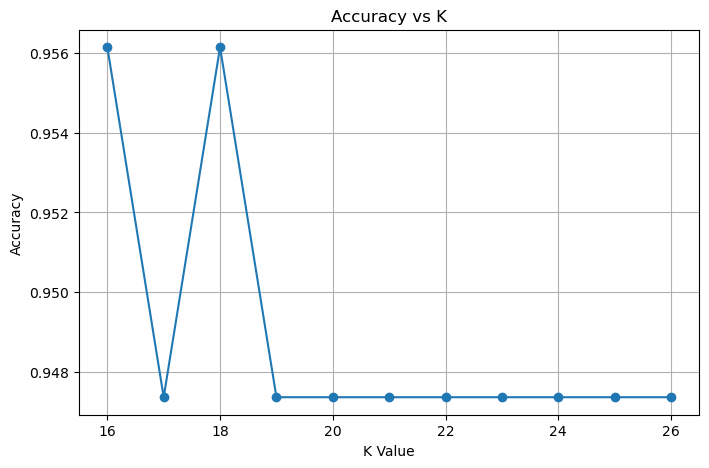

Best K = 16


In [11]:
k_values = list(range(heuristic_k-5, heuristic_k+6))

accuracy=[]

for k in k_values:

    model=KNeighborsClassifier(n_neighbors=k)

    model.fit(X_train,y_train)

    pred=model.predict(X_test)

    accuracy.append(
        accuracy_score(y_test,pred)
    )

plt.figure(figsize=(8,5))
plt.plot(k_values,accuracy,marker='o')
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("Accuracy vs K")
plt.grid(True)
plt.show()

print("Best K =",k_values[np.argmax(accuracy)])

## Euclidean Distance

The Euclidean distance between two points is given by:

$$
d(x, y) = \sqrt{\sum_{i=1}^{n}(x_i - y_i)^2}
$$

**Suitable for:**
- Continuous numerical data
- Most common KNN problems
- When all features have equal importance after feature scaling



## Manhattan Distance

The Manhattan distance between two points is given by:

$$
d(x, y) = \sum_{i=1}^{n} |x_i - y_i|
$$

**Suitable for:**
- High-dimensional datasets
- Data with outliers
- Grid-based movement (e.g., city block distance)

In [12]:
from sklearn.decomposition import PCA
from matplotlib.colors import ListedColormap

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

X_train,X_test,y_train,y_test=train_test_split(
    X_pca,
    y,
    test_size=0.2,
    random_state=42
)

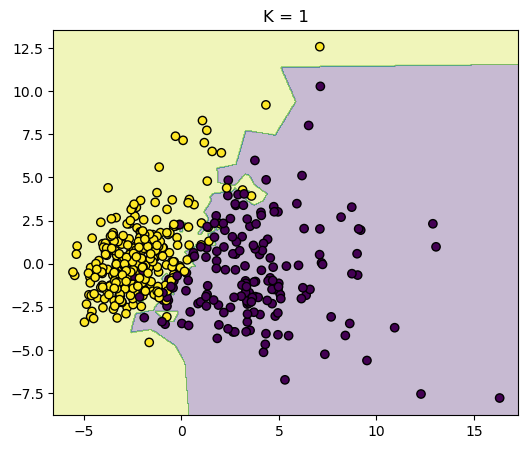

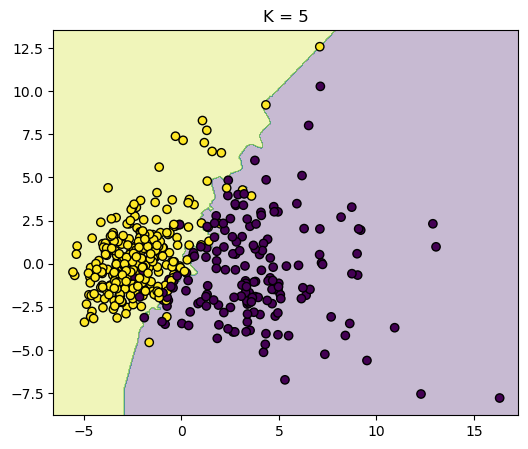

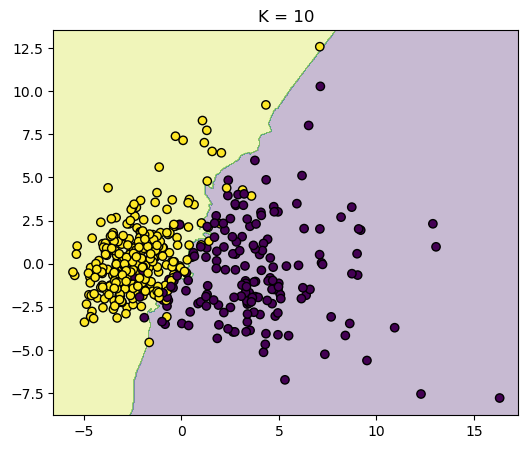

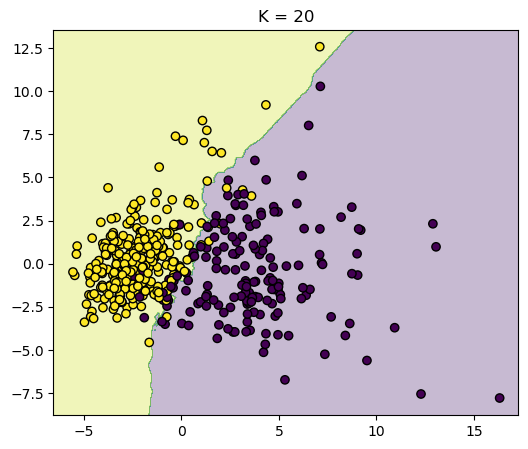

In [13]:
def plot_boundary(k):

    model=KNeighborsClassifier(n_neighbors=k)

    model.fit(X_train,y_train)

    x_min,x_max=X_train[:,0].min()-1,X_train[:,0].max()+1
    y_min,y_max=X_train[:,1].min()-1,X_train[:,1].max()+1

    xx,yy=np.meshgrid(
        np.arange(x_min,x_max,0.05),
        np.arange(y_min,y_max,0.05)
    )

    Z=model.predict(
        np.c_[xx.ravel(),yy.ravel()]
    )

    Z=Z.reshape(xx.shape)

    plt.figure(figsize=(6,5))

    plt.contourf(xx,yy,Z,alpha=0.3)

    plt.scatter(
        X_train[:,0],
        X_train[:,1],
        c=y_train,
        edgecolor='k'
    )

    plt.title(f"K = {k}")

    plt.show()

for k in [1,5,10,20]:
    plot_boundary(k)

### Analysis of Decision Boundary

- **K = 1:** The decision boundary is highly irregular and sensitive to noise, resulting in overfitting.
- **K = 5:** The boundary becomes smoother while still capturing important patterns in the data.
- **K = 10:** The classifier produces a more generalized decision boundary with reduced variance.
- **K = 20:** The boundary becomes much smoother, which may lead to underfitting as some important decision regions are ignored.

As the value of K increases, the decision boundary becomes smoother, reducing overfitting but increasing the risk of underfitting.

# Task 4: Cross Validation
##### 1.Apply K-Fold Cross Validation (k = 5 or 10).
##### 2.Compute mean accuracy for different K values.
#### 3.Compare cross-validation results with train-test split results.
##### 4.Select best K based on both heuristic + validation results.


In [14]:


# Heuristic K value obtained in Task 3
heuristic_k = int(np.sqrt(len(X_train)))
print("Heuristic K =", heuristic_k)

# K values around heuristic K (K ± 5)
k_range = range(max(1, heuristic_k - 5), heuristic_k + 6)

cv_accuracies = []
test_accuracies = []

for k in k_range:

    knn = KNeighborsClassifier(n_neighbors=k)

    # 5-Fold Cross Validation
    cv_scores = cross_val_score(
        knn,
        X_train,
        y_train,
        cv=5,
        scoring='accuracy'
    )

    cv_accuracies.append(cv_scores.mean())

    # Train-Test Evaluation
    knn.fit(X_train, y_train)

    y_pred = knn.predict(X_test)

    test_accuracies.append(
        accuracy_score(y_test, y_pred)
    )

# Plot Cross Validation Accuracy
plt.figure(figsize=(8,5))

plt.plot(
    list(k_range),
    cv_accuracies,
    marker='o',
    linewidth=2
)

plt.xlabel("K Value")
plt.ylabel("Mean Cross Validation Accuracy")
plt.title("Cross Validation Accuracy vs K")
plt.grid(True)

plt.show()

# Display Results
print("\nComparison of Train-Test and Cross Validation Accuracy\n")

print(f"{'K':<5}{'Train-Test Accuracy':<25}{'Cross Validation Accuracy'}")

for i, k in enumerate(k_range):

    print(f"{k:<5}{test_accuracies[i]:<25.4f}{cv_accuracies[i]:.4f}")

# Best K
best_index = np.argmax(cv_accuracies)

best_k = list(k_range)[best_index]

print("\n------------------------------------")
print("Heuristic K               :", heuristic_k)
print("Best K from Validation    :", best_k)
print("Train-Test Accuracy       :", round(test_accuracies[best_index],4))
print("Cross Validation Accuracy :", round(cv_accuracies[best_index],4))
print("------------------------------------")

Heuristic K = 21


NameError: name 'cross_val_score' is not defined

# Task 5: Classification Evaluation
#### Evaluate final model using:
##### 1.Accuracy
##### 2.Precision
##### 3.Recall
##### 4.F1 Score
##### 5.Confusion Matrix
##### 6.ROC Curve and AUC Score


In [ ]:
final_model=KNeighborsClassifier(
    n_neighbors=best_k
)

final_model.fit(X_train,y_train)

prediction=final_model.predict(X_test)

In [ ]:
accuracy_score(y_test,prediction)

0.9736842105263158

In [ ]:
precision_score(y_test,prediction)

0.9722222222222222

In [ ]:
recall_score(y_test,prediction)

0.9859154929577465

In [ ]:
f1_score(y_test,prediction)

0.9790209790209791

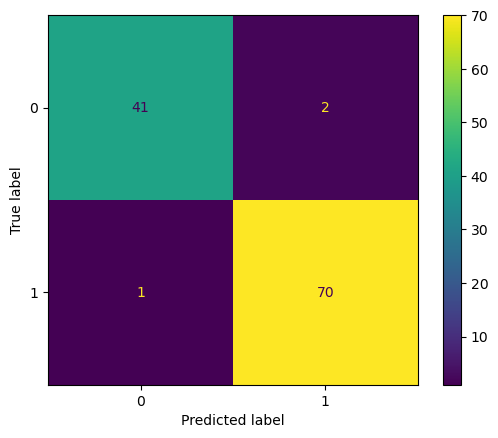

In [ ]:
cm=confusion_matrix(y_test,prediction)

disp=ConfusionMatrixDisplay(cm)

disp.plot()

plt.show()

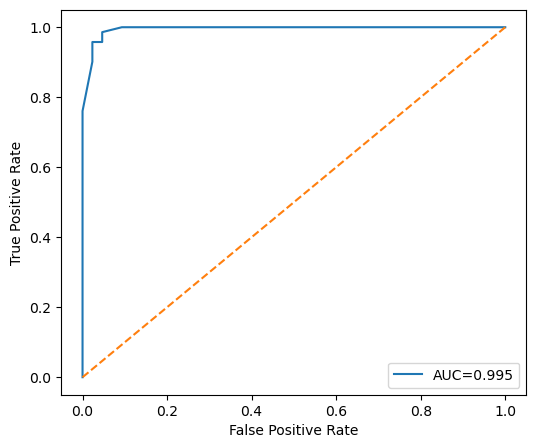

In [ ]:
prob=final_model.predict_proba(X_test)[:,1]

fpr,tpr,_=roc_curve(y_test,prob)

auc=roc_auc_score(y_test,prob)

plt.figure(figsize=(6,5))

plt.plot(fpr,tpr,label="AUC="+str(round(auc,3)))

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.legend()

plt.show()

# Task 6: Comparative Study with Regression (Lab 3 Integration)
###### Reference: Recall Lab 3 (Linear Regression) where you evaluated:
###### MAE
###### MSE
###### RMSE
###### R² Score
#### Tasks:
##### 1.Compare regression evaluation metrics with classification metrics.
##### 2.Explain differences between:
###### Error-based evaluation (Regression)
###### Decision-based evaluation (Classification)
##### 3.Compare:
###### R² Score vs Accuracy
###### RMSE vs F1 Score
###### MAE vs Confusion Matrix
##### 4.Discuss differences in evaluation logic for:
###### Continuous prediction tasks
###### Classification tasks
###### Inference Requirement (short and precise -don't generate )
###### Write a detailed inference covering:
###### How regression metrics measure prediction error magnitude
######  classification metrics measure decision correctness
###### Why is accuracy insufficient in medical diagnosis
###### Why recall and ROC-AUC are more relevant in healthcare
###### Overall comparison between regression and classification evaluation frameworks


| Regression Metrics (Lab 3) | Classification Metrics (Lab 4) | Comparison |
|-----------------------------|---------------------------------|------------|
| **MAE (Mean Absolute Error)** | **Confusion Matrix** | MAE measures the average absolute difference between actual and predicted numerical values. The Confusion Matrix summarizes classification results into True Positives (TP), True Negatives (TN), False Positives (FP), and False Negatives (FN). |
| **MSE (Mean Squared Error)** | **Precision and Recall** | MSE measures the average squared prediction error and penalizes larger errors. Precision and Recall evaluate the correctness of positive class predictions instead of numerical prediction errors. |
| **RMSE (Root Mean Squared Error)** | **F1 Score** | RMSE represents the prediction error in the same units as the target variable. F1 Score is the harmonic mean of Precision and Recall and measures the balance between them. |
| **R² Score** | **Accuracy** | R² Score indicates how well the regression model explains the variance in the target variable. Accuracy measures the proportion of correctly classified instances among all predictions. |

##### Error-based Evaluation (Regression)

Regression evaluation is used when the target variable is continuous. The performance of the model is measured by calculating the difference between the predicted values and the actual values. Metrics such as MAE, MSE, and RMSE quantify prediction errors, while R² Score measures how well the regression model fits the data.

##### Decision-based Evaluation (Classification)

Classification evaluation is used when the target variable consists of categorical classes. Instead of measuring numerical prediction error, classification metrics evaluate whether the predicted class matches the actual class. Metrics such as Accuracy, Precision, Recall, F1 Score, Confusion Matrix, and ROC-AUC measure the correctness of classification decisions.

##### Comparison between R² Score and Accuracy
R² Score is used in regression to measure the proportion of variance in the dependent variable explained by the model. A value closer to 1 indicates a better fit.
Accuracy is used in classification to measure the percentage of correctly classified instances out of the total number of instances.
Although both indicate model performance, R² evaluates prediction quality for continuous values, whereas Accuracy evaluates the correctness of class predictions.

##### Comparison between RMSE and F1 Score
RMSE measures the average magnitude of prediction errors in regression. Lower RMSE indicates better predictive performance.
F1 Score combines Precision and Recall into a single metric using their harmonic mean. Higher F1 Score indicates better classification performance, especially for imbalanced datasets.
RMSE measures numerical prediction error, while F1 Score measures the balance between correctly identified positive predictions and missed positive cases.

##### Comparison between MAE and Confusion Matrix
MAE calculates the average absolute difference between predicted and actual numerical values. Lower MAE indicates more accurate regression predictions.
Confusion Matrix summarizes classification results by displaying:
True Positives (TP)
True Negatives (TN)
False Positives (FP)
False Negatives (FN)
MAE provides a single numerical error value, whereas the Confusion Matrix gives a detailed breakdown of classification outcomes.

##### Evaluation Logic for Continuous Prediction Tasks

Continuous prediction tasks involve predicting numerical values such as house prices, temperature, or sales. The performance of these models is evaluated by measuring the magnitude of prediction errors using metrics like MAE, MSE, RMSE, and R² Score. Smaller error values and higher R² indicate better regression performance.

##### Evaluation Logic for Classification Tasks

Classification tasks involve predicting categorical labels such as Benign/Malignant, Spam/Not Spam, or Pass/Fail. Performance is evaluated by measuring the correctness of predicted class labels using metrics such as Accuracy, Precision, Recall, F1 Score, Confusion Matrix, and ROC-AUC. These metrics help assess how effectively the classifier distinguishes between different classes.

##### Inference

Regression evaluation metrics measure the magnitude of prediction errors by calculating the difference between predicted and actual continuous values. Metrics such as MAE, MSE, and RMSE quantify prediction error, while R² Score indicates how well the regression model explains the variability in the data.

Classification evaluation metrics focus on the correctness of prediction decisions rather than numerical error. Metrics such as Accuracy, Precision, Recall, F1 Score, Confusion Matrix, and ROC-AUC evaluate how effectively the model classifies observations into the correct categories.

In medical diagnosis, Accuracy alone is insufficient because a model may achieve high accuracy even while missing patients with the disease. A False Negative (predicting a cancer patient as healthy) can have serious consequences. Therefore, Recall is more important because it measures the ability of the model to correctly identify actual positive cases, thereby reducing missed diagnoses.

Similarly, ROC-AUC is a valuable evaluation metric in healthcare because it measures the model's ability to distinguish between positive and negative classes across different decision thresholds. A higher ROC-AUC indicates better discrimination between malignant and benign cases.

Overall, regression and classification evaluation frameworks serve different objectives. Regression metrics assess the magnitude of prediction errors for continuous outputs, whereas classification metrics assess the correctness of decision-making for categorical outputs. Selecting appropriate evaluation metrics based on the problem type is essential for building reliable and effective machine learning models, particularly in critical applications such as healthcare.

# part7

### 1.Why is KNN called a lazy learning algorithm?

Because it stores all training data and performs computation only during prediction.


### 2. Why is feature scaling required?

Distance calculations become biased toward features with larger numerical values.

### 3. Explain √n heuristic.

A common rule where
K=root(n)
​


where n is the number of training samples. It provides a good starting point for selecting K.

### 4. Why Cross Validation?

It evaluates the model on multiple data splits, giving more reliable and stable performance than a single train-test split.

### 5. Effect of K on Bias-Variance
Small K → Low bias, High variance
Large K → High bias, Low variance
### 6. Why Recall is important in Cancer Prediction?

Missing a cancer patient (False Negative) is much more dangerous than incorrectly predicting cancer (False Positive). High recall minimizes false negatives.

### 7. Limitation of Large K

Very large K oversmooths the decision boundary, causing underfitting and reduced prediction accuracy.